# GujEstateAI — Phase 3: Feature Engineering
**Input :** `data/processed/cleaned.csv`  
**Output:** `data/processed/features.csv` + `models/encoders.pkl`  
**Goal  :** Turn raw columns into ML-ready features  

Run cells one by one, top to bottom.
---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully")

Libraries imported successfully


## Cell 2 — Load Cleaned Data

In [2]:
df = pd.read_csv("../data/processed/cleaned.csv")

print(f"Cleaned data loaded")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
df.head(3)

Cleaned data loaded
  Rows    : 13,425
  Columns : 39


,projectRegId,projectName,promoterName,projectType,promoterType,projectAddress,underRedevelopment,distName,tpo_code,startDate,...,totalLandCost,avgEstimatedCost_AllProjects,totalCarpetArea_form3A,totalBuiltupArea_form3A,totalSquareFootBuild,AvgSquareFootBuild,avgCostPerSqFt,avgCostPerUnit,duration_months,booking_rate
0,4258,68 SHOPS + 1228 LIG-2 + 432 MIG-1 AT GOTA,GUJARAT HOUSING BOARD,Mixed Development,COMPETENT AUTHORITY/ GOVERNMENT,VASANTNAGAR TOWNSHIP,NO,Ahmedabad,AUDA,2014-05-13,...,2308993.0,2.045715e+09,174950.56,336330.72,174950.56,174950.56,11693.105144,591931.508391,51.0,0.957755
1,5212,SHREE KUBERJI VALENTINE TEXTILE MARKET,SHREE KUBERJI BUILDCON,Commercial,PARTNERSHIP FIRM,"BLOCK NO:258-259,TP:35,SAROLI-KUMBHARIYA",NO,Surat,SUDA,2018-01-01,...,377581896.0,2.448422e+09,46423.44,46423.44,46423.44,46423.44,52741.069942,765131.842500,78.0,0.214375
2,10965,Construction of EWS - I and EWS-II (2560 HOUS...,SURAT URBAN DEVELOPMENT AUTHORITY,Residential/Group Housing,COMPETENT AUTHORITY/ GOVERNMENT,TP SCHEME NO 30 AT VANAKLA,NO,Surat,SUDA,2020-10-01,...,0.0,2.394000e+09,94350.08,94350.08,94350.08,94350.08,25373.587389,935156.250000,50.0,0.000000


## Cell 3 — Feature 1: Log Transform of Cost
`totalEstimatedCost` has very high range (lakhs to crores).  
Log transform makes it easier for ML models to learn from it.  
We keep both — original and log version.

Created: log_cost, log_units

  totalEstimatedCost range  : 300000.0 to 3386588012.0
  log_cost range            : 12.61 to 21.94



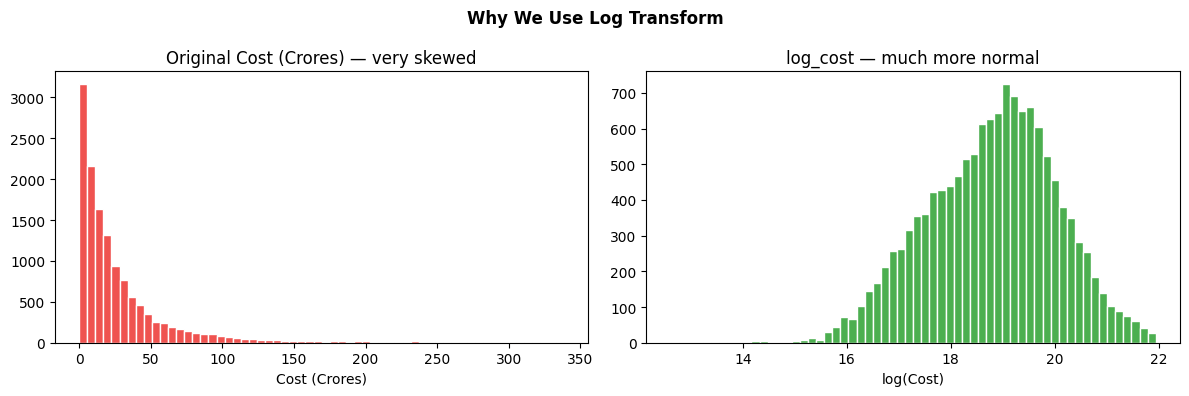

Chart saved to reports/11_log_transform.png


In [3]:
# log1p means log(1 + value) — safe even if value is 0
df["log_cost"]  = np.log1p(df["totalEstimatedCost"])
df["log_units"] = np.log1p(df["totalUnits"])

print("Created: log_cost, log_units")
print()
print("  totalEstimatedCost range  :", df["totalEstimatedCost"].min(), "to", df["totalEstimatedCost"].max())
print("  log_cost range            :", round(df["log_cost"].min(),2), "to", round(df["log_cost"].max(),2))
print()

# Plot to show why log transform helps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["totalEstimatedCost"] / 1e7, bins=60, color="#EF5350", edgecolor="white")
axes[0].set_title("Original Cost (Crores) — very skewed")
axes[0].set_xlabel("Cost (Crores)")

axes[1].hist(df["log_cost"], bins=60, color="#4CAF50", edgecolor="white")
axes[1].set_title("log_cost — much more normal")
axes[1].set_xlabel("log(Cost)")

plt.suptitle("Why We Use Log Transform", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/11_log_transform.png", dpi=150)
plt.show()
print("Chart saved to reports/11_log_transform.png")

## Cell 4 — Feature 2: Cost Per Unit
How much does each unit cost on average?  
This captures the project's price tier (affordable vs luxury).

In [4]:
df["cost_per_unit"] = df["totalEstimatedCost"] / df["totalUnits"]

# Replace infinite or very large values with median (safety)
median_cpu = df["cost_per_unit"].median()
df["cost_per_unit"] = df["cost_per_unit"].replace([np.inf, -np.inf], np.nan)
df["cost_per_unit"] = df["cost_per_unit"].fillna(median_cpu)

print("Created: cost_per_unit")
print()
print(f"  Min    : Rs {df['cost_per_unit'].min():>12,.0f}")
print(f"  Median : Rs {df['cost_per_unit'].median():>12,.0f}")
print(f"  Max    : Rs {df['cost_per_unit'].max():>12,.0f}")

Created: cost_per_unit

  Min    : Rs        3,610
  Median : Rs    1,989,155
  Max    : Rs  388,049,633


## Cell 5 — Feature 3: Land Cost Ratio
What fraction of total cost is just land?  
High land ratio = expensive location. Low = mostly construction cost.

In [5]:
df["land_cost_ratio"] = df["totalLandCost"] / df["totalEstimatedCost"]

# Clip between 0 and 1 (ratio should never exceed 100%)
df["land_cost_ratio"] = df["land_cost_ratio"].clip(0, 1)

print("Created: land_cost_ratio")
print()
print(f"  Min    : {df['land_cost_ratio'].min():.4f}")
print(f"  Median : {df['land_cost_ratio'].median():.4f}  ({df['land_cost_ratio'].median()*100:.1f}% is land cost)")
print(f"  Max    : {df['land_cost_ratio'].max():.4f}")

# Show by project type
print()
print("  Land cost ratio by project type:")
ratio_by_type = df.groupby("projectType")["land_cost_ratio"].mean().round(3)
for pt, val in ratio_by_type.items():
    print(f"    {pt:<30}  {val:.3f}  ({val*100:.1f}%)")

Created: land_cost_ratio

  Min    : 0.0000
  Median : 0.2095  (20.9% is land cost)
  Max    : 1.0000

  Land cost ratio by project type:
    Commercial                      0.296  (29.6%)
    Mixed Development               0.193  (19.3%)
    Plotted Development             0.675  (67.5%)
    Residential/Group Housing       0.241  (24.1%)


## Cell 6 — Feature 4: Sell to Develop Ratio
How much selling price vs development cost?  
High ratio = good profit margin for the promoter.

In [6]:
df["sell_dev_ratio"] = df["totalSellingAmount"] / df["totalDevelopCost"]

# Handle division by zero and infinity
df["sell_dev_ratio"] = df["sell_dev_ratio"].replace([np.inf, -np.inf], np.nan)
median_sdr = df["sell_dev_ratio"].median()
df["sell_dev_ratio"] = df["sell_dev_ratio"].fillna(median_sdr)

# Remove extreme values (top 1%)
upper = df["sell_dev_ratio"].quantile(0.99)
df["sell_dev_ratio"] = df["sell_dev_ratio"].clip(0, upper)

print("Created: sell_dev_ratio")
print()
print(f"  Median : {df['sell_dev_ratio'].median():.2f}  (selling = {df['sell_dev_ratio'].median():.1f}x develop cost)")
print(f"  Min    : {df['sell_dev_ratio'].min():.2f}")
print(f"  Max    : {df['sell_dev_ratio'].max():.2f}")

Created: sell_dev_ratio

  Median : 1.50  (selling = 1.5x develop cost)
  Min    : 0.00
  Max    : 13.97


## Cell 7 — Feature 5: Is Redevelopment Project?
Convert the YES/NO column into 1/0 (number).  
ML models need numbers, not text.

In [7]:
df["is_redevelop"] = (df["underRedevelopment"] == "YES").astype(int)

print("Created: is_redevelop  (1 = YES, 0 = NO)")
print()
print(f"  Redevelopment projects : {df['is_redevelop'].sum():,}  ({df['is_redevelop'].mean()*100:.1f}%)")
print(f"  Normal projects        : {(df['is_redevelop']==0).sum():,}  ({(df['is_redevelop']==0).mean()*100:.1f}%)")

Created: is_redevelop  (1 = YES, 0 = NO)

  Redevelopment projects : 241  (1.8%)
  Normal projects        : 13,184  (98.2%)


## Cell 8 — Feature 6: Start Quarter
Which quarter of the year did the project start?  
Q1 = Jan-Mar, Q2 = Apr-Jun, Q3 = Jul-Sep, Q4 = Oct-Dec  
Projects starting in different quarters may have different timelines.

In [8]:
df["start_quarter"] = df["startProjectMonth"].apply(
    lambda m: int((int(m) - 1) // 3 + 1)
)

print("Created: start_quarter  (1=Jan-Mar, 2=Apr-Jun, 3=Jul-Sep, 4=Oct-Dec)")
print()
print("Projects per quarter:")
qtr = df["start_quarter"].value_counts().sort_index()
for q, count in qtr.items():
    print(f"  Q{q} : {count:,} projects")

Created: start_quarter  (1=Jan-Mar, 2=Apr-Jun, 3=Jul-Sep, 4=Oct-Dec)

Projects per quarter:
  Q1 : 3,715 projects
  Q2 : 3,595 projects
  Q3 : 2,955 projects
  Q4 : 3,160 projects


## Cell 9 — Feature 7: Promoter Type Simplified
The original `promoterType` has 9 categories.  
We simplify to 4 main groups to reduce noise.

In [9]:
# Map to 4 simple groups
def simplify_promoter(pt):
    pt = str(pt).upper()
    if "PARTNERSHIP" in pt:
        return "Partnership"
    elif "COMPANY" in pt or "LLP" in pt or "LIABILITY" in pt:
        return "Company"
    elif "INDIVIDUAL" in pt or "PROPRIET" in pt:
        return "Individual"
    else:
        return "Other"

df["promoter_type_simple"] = df["promoterType"].apply(simplify_promoter)

print("Created: promoter_type_simple")
print()
print("Value counts:")
print(df["promoter_type_simple"].value_counts().to_string())

Created: promoter_type_simple

Value counts:
promoter_type_simple
Partnership    10803
Individual      1208
Company          780
Other            634


## Cell 10 — Encode Categorical Columns
ML models can not use text like "Ahmedabad" or "Commercial".  
We use **Label Encoding** to convert text to numbers.  
We save the encoders so we can decode later.

In [10]:
os.makedirs("../models", exist_ok=True)

encoders = {}

# Columns to encode
cat_cols = ["projectType", "distName", "promoter_type_simple"]

for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"Encoded: {col}")
    print(f"  Categories : {list(le.classes_)}")
    print(f"  Numbers    : {list(range(len(le.classes_)))}")
    print()

# Save encoders to disk
joblib.dump(encoders, "../models/encoders.pkl")
print("Encoders saved to models/encoders.pkl")

Encoded: projectType
  Categories : ['Commercial', 'Mixed Development', 'Plotted Development', 'Residential/Group Housing']
  Numbers    : [0, 1, 2, 3]

Encoded: distName
  Categories : ['AHmedabad', 'Ahmedabad', 'Amreli', 'Anand', 'Aravalli', 'Banaskantha', 'Bharuch', 'Bhavnagar', 'Chhota Udaipur', 'Chhota udepur', 'Dahod', 'Gandhinagar', 'Gir Somnath', 'Jamnagar', 'Junagadh', 'Kheda', 'Kutch', 'Mahisagar', 'Mehsana', 'Morbi', 'Navsari', 'Panchmahals', 'Patan', 'Porbandar', 'RAJKOT', 'Rajkot', 'SURAT', 'Sabarkantha', 'Sabar\xa0Kantha', 'Surat', 'Surendranagar', 'Tapi', 'VADODARA', 'Vadodara', 'Valsad']
  Numbers    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]

Encoded: promoter_type_simple
  Categories : ['Company', 'Individual', 'Other', 'Partnership']
  Numbers    : [0, 1, 2, 3]

Encoders saved to models/encoders.pkl


## Cell 11 — Define Feature Sets for Each Module
Here we clearly define which features go into each ML module.  
This makes it easy to load exactly the right columns later.

In [11]:
# ── Module 1: Duration Prediction ───────────────────────────
# Target: duration_months
FEATURES_DURATION = [
    "projectType_enc",        # type of project
    "distName_enc",           # which district
    "promoter_type_simple_enc", # who is building
    "totalUnits",             # how many units
    "log_cost",               # project cost (log scale)
    "totalLandCost",          # land cost
    "is_redevelop",           # redevelopment or new
    "startProjectYear",       # which year started
    "start_quarter",          # which quarter started
    "land_cost_ratio",        # land as fraction of total cost
    "avgCostPerUnit",         # avg cost per unit
]

# ── Module 2: Cost Estimation ────────────────────────────────
# Target: totalEstimatedCost  (or log_cost)
FEATURES_COST = [
    "projectType_enc",
    "distName_enc",
    "promoter_type_simple_enc",
    "totalUnits",
    "duration_months",
    "totalLandCost",
    "totalCarpetArea_form3A",
    "avgCostPerSqFt",
    "is_redevelop",
    "startProjectYear",
]

# ── Module 4: Clustering ─────────────────────────────────────
# No target — unsupervised
FEATURES_CLUSTER = [
    "log_cost",
    "log_units",
    "duration_months",
    "avgCostPerSqFt",
    "booking_rate",
    "land_cost_ratio",
    "projectType_enc",
    "distName_enc",
]

# ── Module 5: Anomaly Detection ──────────────────────────────
# No target — unsupervised
FEATURES_ANOMALY = [
    "totalEstimatedCost",
    "avgCostPerSqFt",
    "duration_months",
    "booking_rate",
    "totalLandCost",
    "land_cost_ratio",
    "totalUnits",
    "cost_per_unit",
]

print("Feature sets defined!")
print()
print(f"  Module 1 (Duration)  : {len(FEATURES_DURATION)} features")
print(f"  Module 2 (Cost)      : {len(FEATURES_COST)} features")
print(f"  Module 4 (Cluster)   : {len(FEATURES_CLUSTER)} features")
print(f"  Module 5 (Anomaly)   : {len(FEATURES_ANOMALY)} features")

Feature sets defined!

  Module 1 (Duration)  : 11 features
  Module 2 (Cost)      : 10 features
  Module 4 (Cluster)   : 8 features
  Module 5 (Anomaly)   : 8 features


## Cell 12 — Check All New Features Exist
Make sure every feature we defined in Cell 11 actually exists in the dataframe.

In [12]:
all_features = list(set(
    FEATURES_DURATION + FEATURES_COST + FEATURES_CLUSTER + FEATURES_ANOMALY
))

print("Checking all features exist in dataframe...")
print("-" * 45)

missing = []
for feat in sorted(all_features):
    exists = feat in df.columns
    status = "OK" if exists else "MISSING!"
    print(f"  {feat:<35}  {status}")
    if not exists:
        missing.append(feat)

print()
if len(missing) == 0:
    print("All features found!")
else:
    print(f"MISSING features: {missing}")

Checking all features exist in dataframe...
---------------------------------------------
  avgCostPerSqFt                       OK
  avgCostPerUnit                       OK
  booking_rate                         OK
  cost_per_unit                        OK
  distName_enc                         OK
  duration_months                      OK
  is_redevelop                         OK
  land_cost_ratio                      OK
  log_cost                             OK
  log_units                            OK
  projectType_enc                      OK
  promoter_type_simple_enc             OK
  startProjectYear                     OK
  start_quarter                        OK
  totalCarpetArea_form3A               OK
  totalEstimatedCost                   OK
  totalLandCost                        OK
  totalUnits                           OK

All features found!


## Cell 13 — Feature Distributions (Visual Check)
Quick look at all the new features we created.

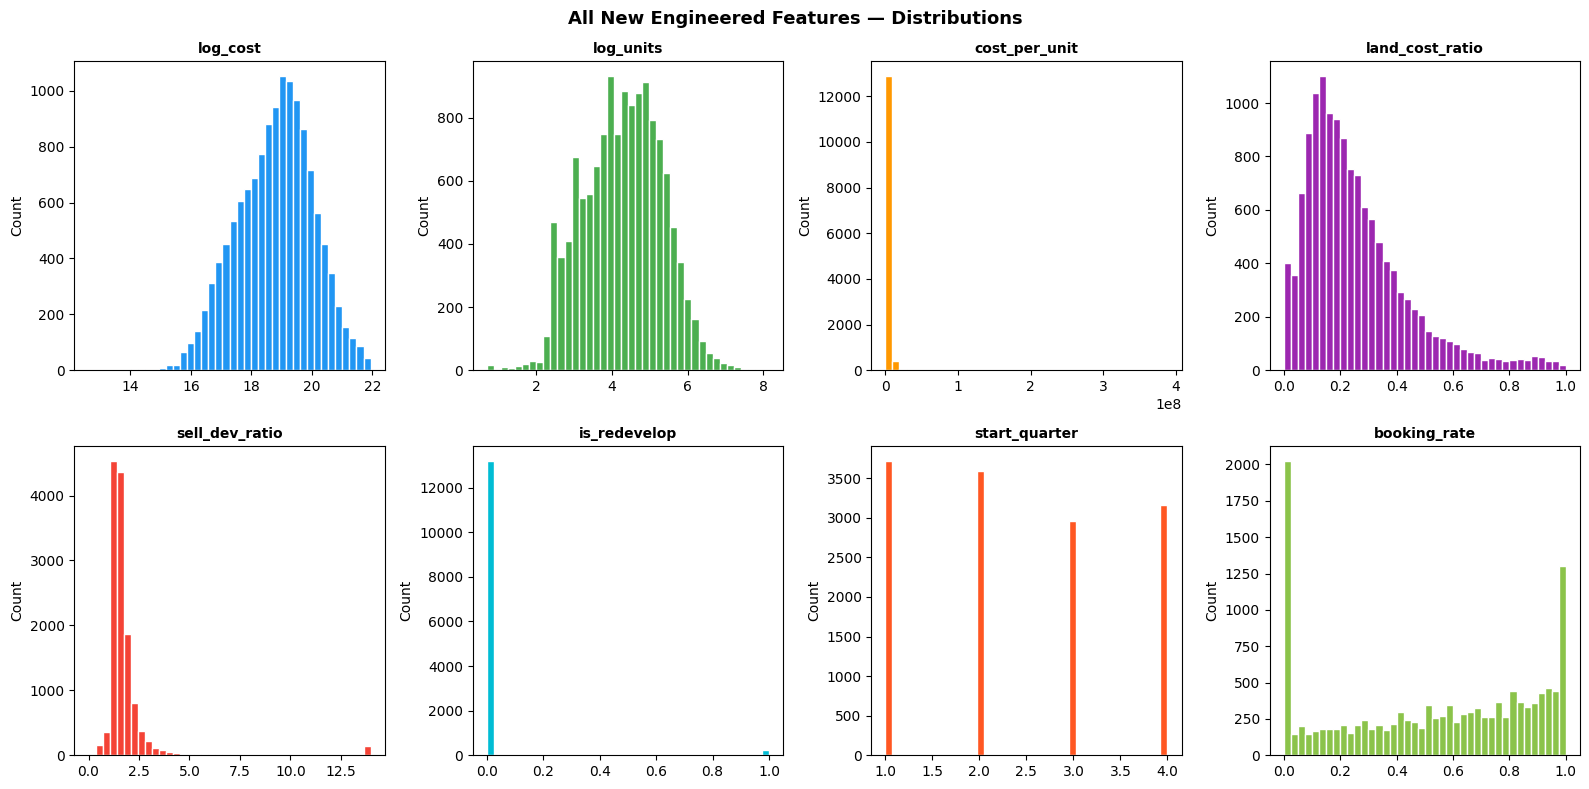

Chart saved to reports/12_feature_distributions.png


In [13]:
new_features = [
    "log_cost", "log_units", "cost_per_unit",
    "land_cost_ratio", "sell_dev_ratio",
    "is_redevelop", "start_quarter", "booking_rate"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0",
          "#F44336","#00BCD4","#FF5722","#8BC34A"]

for i, feat in enumerate(new_features):
    axes[i].hist(df[feat].dropna(), bins=40,
                 color=colors[i], edgecolor="white")
    axes[i].set_title(feat, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Count")

plt.suptitle("All New Engineered Features — Distributions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/12_feature_distributions.png", dpi=150)
plt.show()
print("Chart saved to reports/12_feature_distributions.png")

## Cell 14 — Correlation of New Features with Target Variables
Check how strongly each feature correlates with our two main targets:  
- `duration_months` (Module 1 target)  
- `log_cost` (Module 2 target)

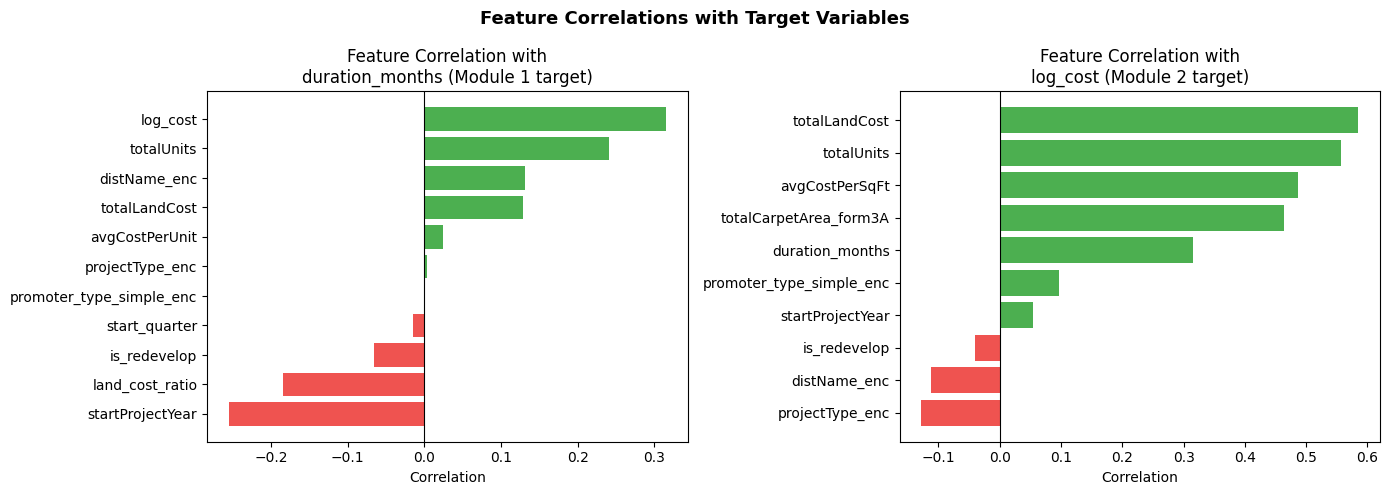

Chart saved to reports/13_feature_correlations.png


In [14]:
check_cols = FEATURES_DURATION + ["duration_months"]
corr_duration = df[check_cols].corr()["duration_months"].drop("duration_months").sort_values()

check_cols2 = FEATURES_COST + ["log_cost"]
corr_cost = df[check_cols2].corr()["log_cost"].drop("log_cost").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration correlations
colors1 = ["#EF5350" if v < 0 else "#4CAF50" for v in corr_duration.values]
axes[0].barh(corr_duration.index, corr_duration.values, color=colors1)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Feature Correlation with\nduration_months (Module 1 target)")
axes[0].set_xlabel("Correlation")

# Cost correlations
colors2 = ["#EF5350" if v < 0 else "#4CAF50" for v in corr_cost.values]
axes[1].barh(corr_cost.index, corr_cost.values, color=colors2)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with\nlog_cost (Module 2 target)")
axes[1].set_xlabel("Correlation")

plt.suptitle("Feature Correlations with Target Variables",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/13_feature_correlations.png", dpi=150)
plt.show()
print("Chart saved to reports/13_feature_correlations.png")

## Cell 15 — Final Summary of All Features
Print a complete table of every feature — original + engineered.

In [15]:
original_features = [
    "projectType", "distName", "promoterType",
    "totalUnits", "totalEstimatedCost", "totalLandCost",
    "avgCostPerSqFt", "avgCostPerUnit", "totalCarpetArea_form3A",
    "duration_months", "booking_rate", "startProjectYear",
]

engineered_features = [
    "log_cost", "log_units", "cost_per_unit",
    "land_cost_ratio", "sell_dev_ratio", "is_redevelop",
    "start_quarter", "promoter_type_simple",
    "projectType_enc", "distName_enc", "promoter_type_simple_enc",
]

print("=" * 55)
print("  FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print()
print(f"  Original features used    : {len(original_features)}")
print(f"  New features created      : {len(engineered_features)}")
print(f"  Total features available  : {len(original_features) + len(engineered_features)}")
print()
print("  NEW FEATURES CREATED:")
print("  " + "-" * 50)
desc = {
    "log_cost"                  : "log(totalEstimatedCost) — normalized cost",
    "log_units"                 : "log(totalUnits) — normalized unit count",
    "cost_per_unit"             : "totalEstimatedCost / totalUnits",
    "land_cost_ratio"           : "totalLandCost / totalEstimatedCost",
    "sell_dev_ratio"            : "totalSellingAmount / totalDevelopCost",
    "is_redevelop"              : "underRedevelopment YES=1 NO=0",
    "start_quarter"             : "Which quarter project started (1-4)",
    "promoter_type_simple"      : "Simplified promoter category (4 groups)",
    "projectType_enc"           : "projectType encoded as number",
    "distName_enc"              : "distName encoded as number",
    "promoter_type_simple_enc"  : "promoter_type_simple encoded as number",
}
for feat, description in desc.items():
    print(f"  {feat:<30}  {description}")
print("=" * 55)

  FEATURE ENGINEERING SUMMARY

  Original features used    : 12
  New features created      : 11
  Total features available  : 23

  NEW FEATURES CREATED:
  --------------------------------------------------
  log_cost                        log(totalEstimatedCost) — normalized cost
  log_units                       log(totalUnits) — normalized unit count
  cost_per_unit                   totalEstimatedCost / totalUnits
  land_cost_ratio                 totalLandCost / totalEstimatedCost
  sell_dev_ratio                  totalSellingAmount / totalDevelopCost
  is_redevelop                    underRedevelopment YES=1 NO=0
  start_quarter                   Which quarter project started (1-4)
  promoter_type_simple            Simplified promoter category (4 groups)
  projectType_enc                 projectType encoded as number
  distName_enc                    distName encoded as number
  promoter_type_simple_enc        promoter_type_simple encoded as number


## Cell 16 — Save Features Data
Save the complete dataframe with all new features to `data/processed/features.csv`.  
This is the file all ML modules will load from.

In [16]:
os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/features.csv", index=False)

print("Features data saved!")
print("  Location : data/processed/features.csv")
print(f"  Shape    : {df.shape[0]:,} rows x {df.shape[1]} columns")
print()

# Also print final column list
print("All columns in features.csv:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")
print()
print("Next step: Open 04_module1_duration.ipynb for Module 1")

Features data saved!
  Location : data/processed/features.csv
  Shape    : 13,425 rows x 50 columns

All columns in features.csv:
   1. projectRegId
   2. projectName
   3. promoterName
   4. projectType
   5. promoterType
   6. projectAddress
   7. underRedevelopment
   8. distName
   9. tpo_code
  10. startDate
  11. location_coordinates
  12. startProjectYear
  13. startProjectMonth
  14. completionDate
  15. EndProjectYear
  16. EndProjectMonth
  17. totalProjects
  18. totalUnits
  19. bookedUnits
  20. noOfInventory
  21. avgUnits
  22. totalEstimatedCost
  23. totalIncurredCost
  24. totalPayableAmountGovernment
  25. totalDevelopCost
  26. totalSellingAmount
  27. bookedSellingAmount
  28. totalReceivedAmount
  29. bookedReceivedAmount
  30. totalLandCost
  31. avgEstimatedCost_AllProjects
  32. totalCarpetArea_form3A
  33. totalBuiltupArea_form3A
  34. totalSquareFootBuild
  35. AvgSquareFootBuild
  36. avgCostPerSqFt
  37. avgCostPerUnit
  38. duration_months
  39. booking_ra